# Example 3: Global sensitivity analysis using multi-task simulations

This notebook demonstrates how to perform global sensitivity analysis using Sobol indices on the [virus-macrophage](https://github.com/MathCancer/PhysiCell/tree/master/sample_projects/virus_macrophage) PhysiCell model. The analysis employs multi-task parallel simulation execution to efficiently explore parameter sensitivity across the entire parameter space. The Sobol method quantifies both first-order and total-order sensitivity indices, providing insights into individual parameter importance and parameter interactions.

The workflow includes:
1. **Sample generation**: Using Sobol sequences to create quasi-random parameter samples that ensure uniform coverage of the parameter space
2. **Multi-task simulation**: Parallel execution of PhysiCell simulations across multiple worker processes to maximize computational efficiency
3. **QoI extraction**: Computing quantities of interest from simulation outputs using custom functions
4. **Statistical analysis**: Calculating summary statistics across multiple replicates to account for stochastic variability
5. **Sensitivity computation**: Computing first-order (S1) and total-order (ST) Sobol sensitivity indices

The analysis focuses on the following parameters:
- **viral_replication_rate**: The rate of virus replication inside epithelial cells
- **min_virion_count**: The minimum number of virions required for a macrophage to recognize them as non-self

The quantities of interest examined include cell population dynamics and molecular concentrations over time.

In [1]:
# Database name to save all simulations
db_path = "ex3_PhysiCell_SA_MultiTask.db"
model_config  = {"ini_path": "Model_Struct.ini", "struc_name": 'physicell_model_2'}
# Define parameter space
params_info = {
    "viral_replication_rate": {"lower_bound": 0.05, "upper_bound": 0.20, "ref_value": 0.125},
    "min_virion_count": {"lower_bound": 0.5, "upper_bound": 1.5, "ref_value": 1.0}
}
# Define the name of sampler, the sampler needs to be compatible with SA method selected
sampler = "Sobol"
# If you want a particular qoi function you can create your own summary function and assing to ModelAnalysisContext (qoi_funcs={} and context.summary_function)
qoi_funcs = {
    "epithelial_live": "lambda df: len( df[ (df['dead'] == False) & (df['cell_type'] == 'epithelial cell') ] )",
    "interferon_mean": "lambda df_subs: df_subs['interferon'].mean()"
}

## Create the Model Analysis Context, Generate Samples, and Run Simulations

In [2]:
from uq_physicell import get_physicell
from uq_physicell.model_analysis import ModelAnalysisContext, run_simulations

# Get PhysiCell, if not exist, it will be downloaded - Alternatively, you can change the paths in the Model_Struct.ini file to a PhysiCell folder on your system.
get_physicell(target_dir=".")
# Setup the context and number of workers to run simulations
context = ModelAnalysisContext(db_path, model_config, sampler, params_info, qoi_funcs, num_workers=8)
# Generate the samples using the specified sampler
# Sobol' sequence is a quasi-random low-discrepancy sequence used to generate uniform smaples of parameter space. 
# The UQ_physicell default is calculate second order of sensitivity, then generate a total of N*(2D+2) samples, where D is number of parameters.
context.generate_samples(N=8)
print(f"Generated {len(context.dic_samples)} samples using {sampler}")
run_simulations(context)
print(f"Simulations completed and results stored in the database: {db_path}.")

PhysiCell already exists at: PhysiCell-master
Skipping download. Use force_download=True to override.
Generated 48 samples using Sobol
Simulations completed and results stored in the database: ex3_PhysiCell_SA_MultiTask.db.


## Load the database and Calculate the summary statistics

In [3]:
from uq_physicell.database.ma_db import load_output
from uq_physicell.model_analysis.utils import calculate_qoi_statistics

# Load QoIs structure from db (This does NOT load the all mcds lists to avoid out of memory error)
df_qois_data = load_output(db_path, load_data=False)
df_summary_qois, df_relative_mcse = calculate_qoi_statistics(df_qois_data, qoi_funcs, db_path)
display(df_summary_qois)

Calculating QoIs from DataFrame...
Number of replicates: 5


,epithelial_live_0,epithelial_live_1,epithelial_live_2,epithelial_live_3,epithelial_live_4,epithelial_live_5,epithelial_live_6,epithelial_live_7,epithelial_live_8,interferon_mean_0,...,interferon_mean_8,time_0,time_1,time_2,time_3,time_4,time_5,time_6,time_7,time_8
SampleID,,,,,,,,,,,,,,,,,,,,,
0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,0.0,...,0.000000e+00,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0
1,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,0.0,...,0.000000e+00,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0
2,1010.0,1006.0,1003.0,978.4,962.8,929.4,898.4,867.2,816.2,0.0,...,6.676239e-03,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0
3,1010.0,1006.6,1003.4,964.2,943.6,915.6,881.6,844.6,731.0,0.0,...,6.880522e-03,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0
4,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,0.0,...,0.000000e+00,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0
5,1010.0,1006.4,961.8,913.6,635.8,203.2,115.2,0.0,0.0,0.0,...,7.222999e-203,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0
6,1010.0,1006.8,1004.0,948.4,921.4,814.0,450.0,355.0,349.6,0.0,...,4.424005e-04,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0
7,1010.0,1006.2,1003.2,1001.8,992.0,986.0,985.4,985.4,985.4,0.0,...,7.163952e-322,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0
8,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,1010.0,0.0,...,0.000000e+00,0.0,360.0,720.0,1080.0,1440.0,1800.0,2160.0,2520.0,2880.0


### Plot the summary stats and relative Monte Carlo Standard Error (MCSE)

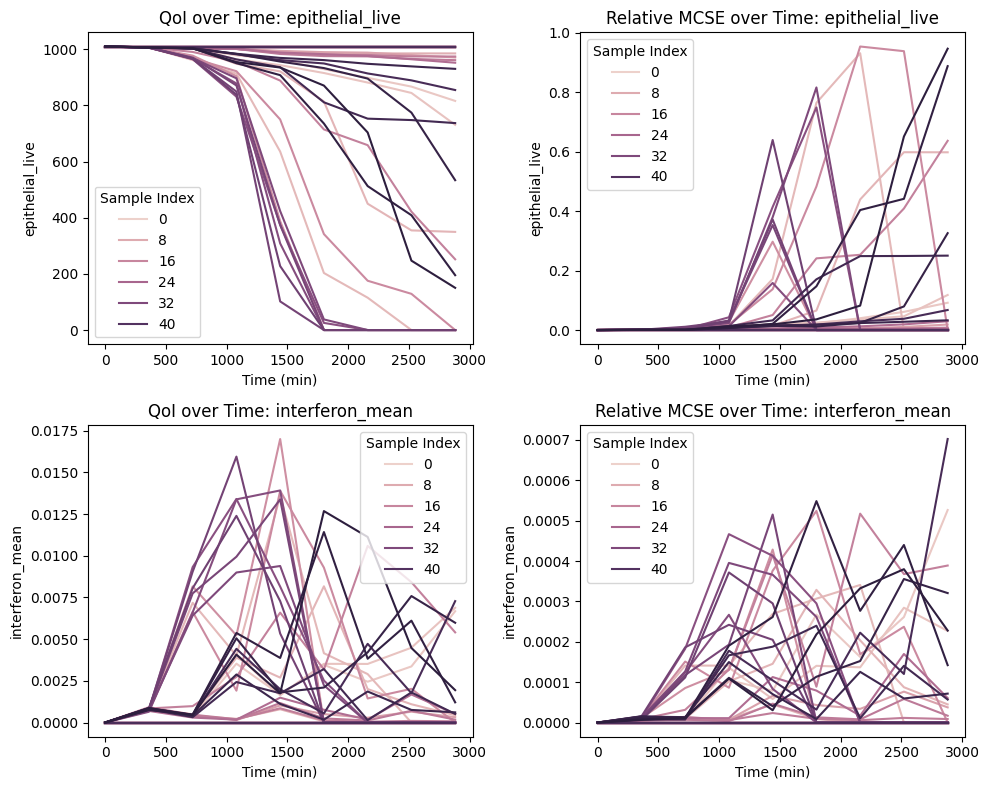

In [4]:
import matplotlib.pyplot as plt
from uq_physicell.gui.utils import plot_qoi_over_time

fig, axes = plt.subplots(len(qoi_funcs.keys()), 2, figsize=(10, 4*len(qoi_funcs.keys())))
for ax_id, qoi_name in enumerate(qoi_funcs.keys()):
    # Plot QoI time series
    plot_qoi_over_time(df_summary_qois, qoi_name, axes[ax_id,0])
    axes[ax_id,0].set_title(f"QoI over Time: {qoi_name}")
    # Plot mcse
    plot_qoi_over_time(df_relative_mcse, qoi_name, axes[ax_id,1])
    axes[ax_id,1].set_title(f"Relative MCSE over Time: {qoi_name}")

# Ensure proper layout and save the figure
plt.tight_layout()  # This will automatically adjust spacing to prevent overlaps

## Run the Sobol Sensitivity Analysis

Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 0.0
Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 360.0
Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 720.0
Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 1080.0
Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 1440.0
Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 1800.0
Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 2160.0
Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 2520.0
Running Sobol Sensitivity Analysis for QoI: epithelial_live and time: 2880.0
Running Sobol Sensitivity Analysis for QoI: interferon_mean and time: 0.0
Running Sobol Sensitivity Analysis for QoI: interferon_mean and time: 360.0
Running Sobol Sensitivity Analysis for QoI: interferon_mean and time: 720.0
Running Sobol Sensitivity Analysis for QoI: interferon_mean and time: 1080.0
Running S

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/SALib/analyze/sobol.py:141: RuntimeWarning: invalid value encountered in divide
  Y = (Y - Y.mean()) / Y.std()


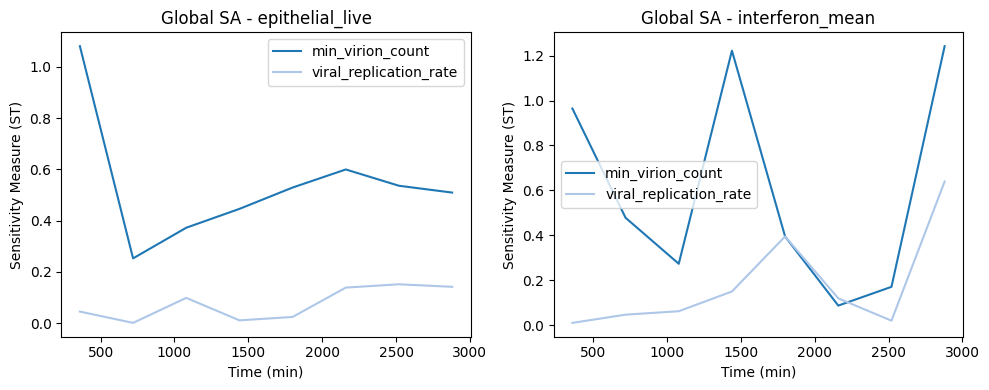

In [5]:
from uq_physicell.gui.utils import get_global_SA_parameters, plot_global_sa_results
from uq_physicell.model_analysis import run_global_sa

sa_method = "Sobol Sensitivity Analysis"
global_SA_parameters = get_global_SA_parameters(db_path)
sa_results, qoi_time_values = run_global_sa(global_SA_parameters, sa_method, qoi_funcs, df_summary_qois)

# Plot Global SA results
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax_id, qoi_name in enumerate(qoi_funcs.keys()):
    plot_global_sa_results(global_SA_parameters, sa_method, qoi_time_values, sa_results, qoi_name, 'ST' , axes[ax_id])
    axes[ax_id].set_title(f'Global SA - {qoi_name}')
    axes[ax_id].legend(loc='best')

plt.tight_layout()